In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
filename = '../gamora_nebula.jpg'
im = cv2.imread(filename)


In [3]:
#redimensiona a imagem
new_width = int(im.shape[1] * .5)
new_height = int(im.shape[0] * .5)
dim = (new_width, new_height)
im_resized = cv2.resize(im, dim, interpolation = cv2.INTER_AREA)

In [5]:
def calculate_threshold_value(color):
    # Converter a cor do picker para o espaço de cores HSV
    color_hsv = cv2.cvtColor(np.uint8([[color]]), cv2.COLOR_RGB2HSV)[0][0]
    # Obter o componente de valor (V) da cor HSV
    v_value = color_hsv[2]
    # Definir um fator para ajustar o valor de thresholding
    threshold_factor = 0.8  # Ajuste conforme necessário
    # Calcular o valor de threshold com base no componente de valor (V)
    threshold_value = v_value * threshold_factor
    return threshold_value

## Tentativa 1

In [16]:
# Converte para RGB
image = im_resized

green1 =[44, 70, 34]
green2 =[128, 204, 223]
blue1 = [46, 32,  3]
blue2 = [228, 190, 108]


# Define os intervalos de cores para cada personagem
green_interval = (green1, green2)  # Intervalo de cores para o personagem 1 (verde)
blue_interval = (blue1, blue2)  # Intervalo de cores para o personagem 2 (azul)

# Aplica o threshold para identificar as regiões de interesse (ROIs) de cada personagem
mask_person1 = cv2.inRange(image, np.array(green_interval[0]), np.array(green_interval[1]))
mask_person2 = cv2.inRange(image, np.array(blue_interval[0]), np.array(blue_interval[1]))

# Cria uma cópia da imagem original para a troca de cores
res = image.copy()

# Define as novas cores para cada personagem
new_color_person1 = (212, 50,50)  # Nova cor para o personagem 1 (azul)
new_color_person2 = (50,212,50)  # Nova cor para o personagem 2 (verde)

# Aplica as novas cores às regiões de interesse de cada personagem
res[mask_person1 > 0] = new_color_person1
res[mask_person2 > 0] = new_color_person2

# Mostra as imagens resultantes
cv2.imshow('original', image)
cv2.imshow('swap', res)
cv2.imshow('mask1', mask_person1)
cv2.imshow('mask2', mask_person2)

cv2.waitKey(0)
cv2.destroyAllWindows()

## Tentativa 2

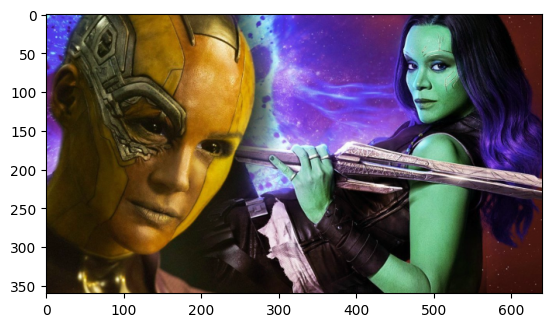

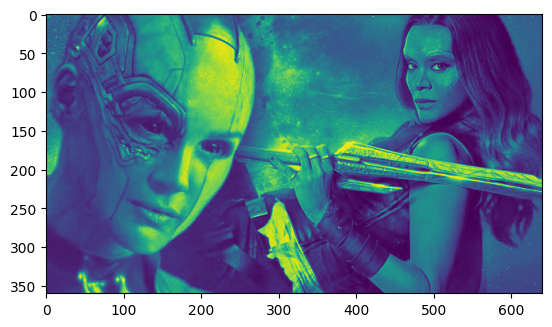

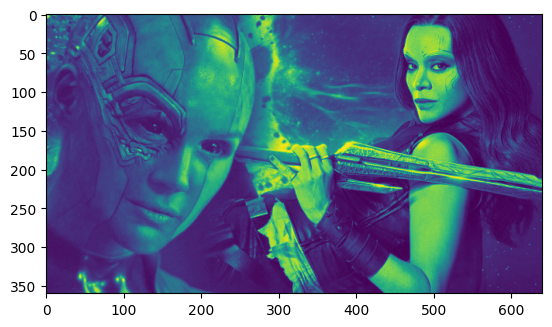

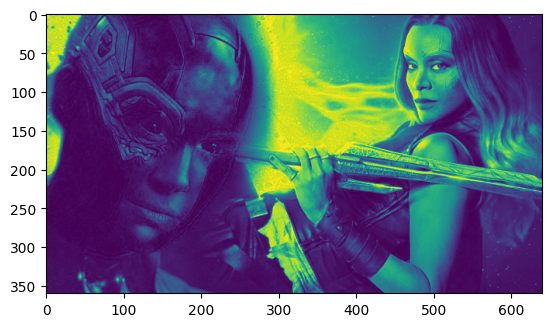

In [19]:
test_img = im_resized#cv2.cvtColor(im_resized, cv2.COLOR_BGR2H)
plt.imshow(test_img)
plt.show()
r, g, b = cv2.split(test_img)
plt.imshow(r)
plt.show()
plt.imshow(g)
plt.show()
plt.imshow(b)
plt.show()


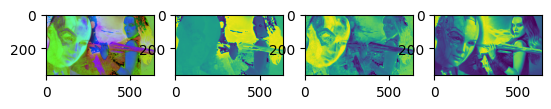

130.4 112.0


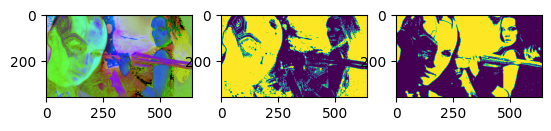

In [10]:


# Converte para RGB
image =  cv2.cvtColor(im_resized, cv2.COLOR_BGR2HSV)

# Split nos canais de cores
r, g, b = cv2.split(image)

imgs = [image, r, g, b]
for i in range(len(imgs)):
   plt.subplot(1,len(imgs),i+1),plt.imshow(imgs[i])
plt.show()

img_ref = r
green = [31,163,134]
blue = [53,92,140]   

value1 = calculate_threshold_value(green)
value2 = calculate_threshold_value(blue)
print(value1, value2)
# Thresholding para identificar as regiões de interesse (ROIs) de cada personagem
ret, mask_person1 = cv2.threshold(g, value1, 255, cv2.THRESH_BINARY)  # Exemplo para o personagem 1
ret, mask_person2 = cv2.threshold(b, value2, 255, cv2.THRESH_BINARY)  # Exemplo para o personagem 2

imgs = [image, mask_person1,mask_person2]
for i in range(len(imgs)):
   plt.subplot(1,len(imgs),i+1),plt.imshow(imgs[i])
plt.show()

# Cria máscaras RGB para cada personagem
# mask_person1 = cv2.cvtColor(mask_person1, cv2.COLOR_GRAY2RGB)
# mask_person2 = cv2.cvtColor(mask_person2, cv2.COLOR_GRAY2RGB)

# # Aplica as máscaras para obter as regiões de interesse de cada personagem
# person1 = cv2.bitwise_and(image, mask_person1)
# person2 = cv2.bitwise_and(image, mask_person2)

# #Troca as cores entre as regiões de interesse
# person1[np.where((person1 == [255, 255, 255]).all(axis=2))] = person2[np.where((person2 == [255, 255, 255]).all(axis=2))]
# person2[np.where((person2 == [255, 255, 255]).all(axis=2))] = person1[np.where((person1 == [255, 255, 255]).all(axis=2))]
# res = image.copy()
# res[mask_person1 > 0] = (202, 141,  43)
# res[mask_person2 > 0] = (116, 196, 149)


# resss = cv2.bitwise_and(person1, person2)

# Mostra as imagens resultantes
# plt.subplot(121), plt.imshow(person1)
# plt.subplot(122), plt.imshow(person2)
# plt.show()

# res = cv2.cvtColor(res, cv2.COLOR_BGR2RGB)

# cv2.imshow('original',image)
# cv2.imshow('swap',res)
cv2.imshow('mask1',mask_person1)
cv2.imshow('mask2',mask_person2)


cv2.waitKey(0)
cv2.destroyAllWindows()

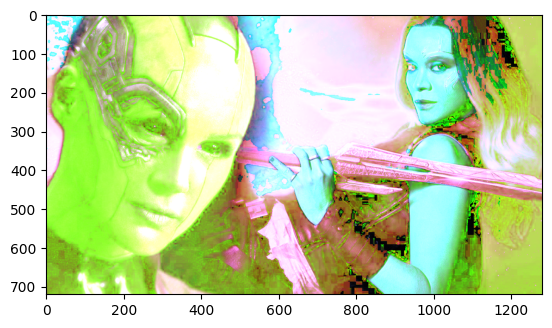

In [15]:
i = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
r,g,b = cv2.split(i)


combined_image = cv2.add(i, im)


plt.imshow(combined_image)